## 🤖 Auswahl des Machine-Learning-Algorithmus

Zur Lösung der Problemstellung wurde ein **überwachtes Klassifikationsmodell** eingesetzt,  
da das Ziel darin besteht, anhand **vor dem Rennen bekannter Merkmale** vorherzusagen,  
ob ein Fahrer eine **Top-10-Platzierung** erreicht oder nicht.

---

### 🧠 Primärer Algorithmus: **Logistische Regression**

#### 📝 Begründung der Modellwahl:
- ✅ Etabliertes **Baseline-Modell** für binäre Klassifikationsprobleme  
- 📊 Besonders geeignet für **strukturierte tabellarische Daten**  
- 🔍 **Gut interpretierbar** – Einfluss einzelner Merkmale über Modellkoeffizienten nachvollziehbar  
- ⚙️ **Geringe Rechenkomplexität** → stabile & reproduzierbare Ergebnisse

---

### 🚀 Zweites Modell: **LightGBM-Klassifikator**

Wir haben erst einen Random Forest probiert und sind dann zu **LightGBM** gewechselt. 
Einfach gesagt: LightGBM baut viele Entscheidungsbäume hintereinander auf, lernt aus den Fehlern der vorherigen Bäume und wird so Schritt für Schritt besser. 
Dadurch ist es oft genauer und schneller als ein einzelner Random Forest. LightGBM kommt gut mit vielen Spalten (z. B. vielen One-Hot-Dummies) zurecht, skaliert bei größeren Datensätzen effizient und kann feinere Muster erkennen

https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html#lightgbm.LGBMClassifier

---

### ✅ Validierung

- **Stratifizierte CV** für robuste Durchschnittsmetriken.  
- **TimeSeriesSplit** für zeitlich korrekte Validierung (keine Durchmischung in die Zukunft), um Generalisierung auf zukünftige Rennen realistisch abzuschätzen.


In [57]:
import pandas as pd
import numpy as np


In [58]:
feature_df = pd.read_csv("../data/processed/driver_race_features.csv")
print(feature_df.shape)
feature_df.head()


(25121, 17)


,season,round,raceId,race_date,driverId,driver_name,constructorId,constructor_name,circuitId,circuit_name,grid,driver_experience,driver_recent_form,constructor_strength,era,grid_bucket,target_top10
0,1950,1,833,1950-05-13,579,Juan Fangio,51,Alfa Romeo,9,Silverstone Circuit,3,0,11.754182,11.823009,1950-1969,front_row_1_3,0
1,1950,1,833,1950-05-13,589,Louis Chiron,105,Maserati,9,Silverstone Circuit,11,0,11.754182,11.823009,1950-1969,mid_11_20,0
2,1950,1,833,1950-05-13,619,Bob Gerard,151,ERA,9,Silverstone Circuit,13,0,11.754182,11.823009,1950-1969,mid_11_20,1
3,1950,1,833,1950-05-13,627,Louis Rosier,154,Talbot-Lago,9,Silverstone Circuit,9,0,11.754182,11.823009,1950-1969,top10_4_10,1
4,1950,1,833,1950-05-13,640,Toulo de Graffenried,105,Maserati,9,Silverstone Circuit,8,0,11.754182,18.000000,1950-1969,top10_4_10,0


## 🗺️ Holdout: letztes Rennen ausklammern

Wir halten das zeitlich letzte Rennen im Datensatz als **Holdout** zurück, um zu sehen, wie gut das Modell auf ein tatsächlich unbekanntes Event **generalisiert**. Ein Holdout bleibt **komplett außerhalb des Trainings**: Wir filtern das **jüngste Rennen (per Datum)**, sichern diese Zeilen separat und trainieren auf dem Rest. So vermeiden wir, dass das Modell Ergebnisse kennt, die es eigentlich vorhersagen soll, und können später die Prognosen mit dem realen Ausgang vergleichen.

Die Daten sind **chronologisch sortiert**, daher ist es sinnvoll, ein Rennen aus der **Zukunftsperspektive** des Modells zu testen. Ein **vergangenes Rennen** als Holdout wäre weniger aussagekräftig, weil das Modell bei **zeitlicher Durchmischung** indirekt Information darüber lernen könnte (**Data Leakage**) und die Generalisierung **überschätzt** würde.


Wir kommen später auf **Marina Circuit** zurück, um die Vorhersagen gegen das **reale Ergebnis** zu spiegeln.

> 🧠 Ein **Holdout** ist ein bewusst zurückgehaltener Datensatz, der **nicht zum Trainieren** verwendet wird. Man trainiert das Modell auf dem übrigen Teil der Daten und prüft es erst danach auf dem Holdout. So sieht man, wie gut das Modell auf **wirklich unbekannte Fälle** generalisiert und ob es **überfittet**. Oft ist der Holdout ein **bestimmter Zeitraum**, eine **Kundengruppe** oder ein **zufällig abgetrennter Teil** der Daten.




In [59]:
# Identify the latest race by date
feature_df["race_date_parsed"] = pd.to_datetime(feature_df["race_date"], errors="coerce")
latest = feature_df.sort_values("race_date_parsed").iloc[-1]

HOLDOUT_SEASON = int(latest["season"])
HOLDOUT_ROUND = int(latest["round"])
HOLDOUT_CIRCUIT_ID = latest["circuitId"]
HOLDOUT_RACEID = latest.get("raceId")
HOLDOUT_CIRCUIT_NAME = latest.get("circuit_name", "")

mask_holdout = (
    (feature_df["season"] == HOLDOUT_SEASON)
    & (feature_df["round"] == HOLDOUT_ROUND)
    & (feature_df["circuitId"].astype(str) == str(HOLDOUT_CIRCUIT_ID))
)

holdout_df = feature_df[mask_holdout].copy()
feature_df_train = feature_df[~mask_holdout].copy()

print("Holdout race:", HOLDOUT_SEASON, HOLDOUT_ROUND, HOLDOUT_CIRCUIT_ID, HOLDOUT_CIRCUIT_NAME)
print("Holdout rows:", holdout_df.shape)
print("Training rows:", feature_df_train.shape)

holdout_path = "../data/processed/holdout_latest_race.csv"
holdout_df.to_csv(holdout_path, index=False)
print("Saved holdout to", holdout_path)

# Clean up helper column if desired
feature_df.drop(columns=["race_date_parsed"], inplace=True)


Holdout race: 2024 24 24 Yas Marina Circuit
Holdout rows: (20, 18)
Training rows: (25101, 18)
Saved holdout to ../data/processed/holdout_latest_race.csv


In [60]:
y = feature_df_train["target_top10"]

X = feature_df_train.drop(columns=[
    "target_top10",
    "race_date",       
    "driver_name",
    "constructor_name",
    "circuit_name"
])

X = X.drop(columns=["raceId"], errors="ignore")

print(X.shape, y.shape)


(25101, 12) (25101,)


## 🧪 Vorbereitung der Daten für das Training

Für das Modelltraining wurden **ausschließlich Pre-Race-Features** verwendet – also Merkmale,  
die **vor Rennbeginn bekannt** sind, um **Datenleckagen (Data Leakage)** zu vermeiden.

---

### 🧾 Die Feature-Matrix enthielt unter anderem:

- 🏁 **Startposition (Grid)** und **Grid-Kategorien**  
- 🧑‍✈️ **Fahrer-Erfahrung** (Anzahl vorheriger Rennen)  
- 📈 **Aktuelle Fahrerform** (rollierender Mittelwert vorheriger Ergebnisse)  
- 🛠️ **Teamstärke** (historische durchschnittliche Platzierungen)  
- 🗺️ **Strecke** und **Epoche** (kategorisch)

---

### ⚙️ Vorverarbeitungsschritte:

- 📊 **Numerische Merkmale** wurden **standardisiert**,  
  um unterschiedliche Wertebereiche auszugleichen  
- 🔤 **Kategorische Merkmale** wurden mittels **One-Hot-Encoding**  
  in numerische Repräsentationen überführt  
- 🧱 Alle Schritte wurden in einer **Pipeline** zusammengefasst,  
  um eine **konsistente und korrekte Anwendung** während jeder Trainingsiteration zu gewährleisten



In [61]:
cat_cols = ["circuitId", "era", "grid_bucket"]

X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print("Encoded:", X_encoded.shape)


Encoded: (25101, 92)


In [62]:
print(y.value_counts())
print(y.value_counts(normalize=True))


target_top10
0    13804
1    11297
Name: count, dtype: int64
target_top10
0    0.549938
1    0.450062
Name: proportion, dtype: float64


In [63]:
X_encoded.dtypes.value_counts()


bool              83
int64              6
float64            2
datetime64[ns]     1
Name: count, dtype: int64

In [64]:
dt_cols = X_encoded.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns
print("Datetime cols in X_encoded:", list(dt_cols))
X_encoded = X_encoded.drop(columns=dt_cols)

Datetime cols in X_encoded: ['race_date_parsed']


### ⚙️ Validierung

Wir nutzen 2 Validierungen, weil sie unterschiedliche Fragen beantworten:

### Stratifizierte Kreuzvalidierung (Vergleich, beide Modelle)

Wir prüfen LogReg und LightGBM zuerst mit stratifizierter CV, um einen allgemeinen Eindruck über alle Daten zu bekommen und die Klassenbalance in jedem Fold zu wahren. Diese Werte dienen dem Modellvergleich, sind aber zeitlich gemischt.

### Zeitreihen-Validierung (entscheidend, beide Modelle)

Für die eigentliche Modellauswahl nutzen wir `TimeSeriesSplit`: train nur auf früheren Rennen, Test auf späteren Rennen. So vermeiden wir zeitliche Lecks und erhalten eine realistischere Aussage zur Generalisierung auf zukünftige Events. Diese Scores sind maßgeblich.

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html  

Beides zusammen zeigt die **allgemeine** Performance (stratifiziert) und die realistisch **zeitbezogene** Performance (Zeit-Split).

In [65]:
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

num_cols = ["grid", "driver_experience", "driver_recent_form", "constructor_strength", "round", "season"]
num_cols = [c for c in num_cols if c in X_encoded.columns]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
    ],
    remainder="passthrough"
)

logreg = LogisticRegression(max_iter=5000, solver="lbfgs")

pipeline_lr = Pipeline([
    ("preprocess", preprocess),
    ("model", logreg)
])

cv = TimeSeriesSplit(n_splits=5)

scoring = ["accuracy", "precision", "recall", "f1"]

scores_lr = cross_validate(
    pipeline_lr,
    X_encoded,
    y,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "average_precision"   # PR-AUC
    ],
    n_jobs=-1,
    error_score="raise"
)

for m in scoring:
    vals = scores_lr[f"test_{m}"]
    print(f"LogReg {m}: mean={vals.mean():.3f}, std={vals.std():.3f}")


LogReg accuracy: mean=0.669, std=0.044
LogReg precision: mean=0.647, std=0.095
LogReg recall: mean=0.560, std=0.103
LogReg f1: mean=0.593, std=0.082


In [66]:
import lightgbm as lgb
from sklearn.model_selection import cross_validate, TimeSeriesSplit

# LightGBM classifier
lgbm = lgb.LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    class_weight='balanced'
)

# Stratified CV (uses existing cv)
scores_lgbm = cross_validate(
    lgbm,
    X_encoded,
    y,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "average_precision"
    ],
    n_jobs=-1,
    error_score="raise",
)

for m in scoring:
    vals = scores_lgbm[f"test_{m}"]
    print(f"LGBM (Stratified) {m}: mean={vals.mean():.3f}, std={vals.std():.3f}")

# Time-aware CV
tscv = TimeSeriesSplit(n_splits=5)
scores_lgbm_ts = cross_validate(
    lgbm,
    X_encoded,
    y,
    cv=tscv,
    scoring=scoring,
    n_jobs=-1,
    error_score="raise",
)

for m in scoring:
    vals = scores_lgbm_ts[f"test_{m}"]
    print(f"LGBM (TimeSeriesSplit) {m}: mean={vals.mean():.3f}, std={vals.std():.3f}")


[LightGBM] [Info] Number of positive: 2074, number of negative: 2112[LightGBM] [Info] Number of positive: 3790, number of negative: 4579

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000734 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1018
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000862 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1150
[LightGBM] [Info] Number of data points in the train set: 4186, number of used features: 41
[LightGBM] [Info] Number of data points in the train set: 8369, number of used features: 54
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Nu

In [67]:
comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy_mean": scores_lr["test_accuracy"].mean(),
        "Precision_mean": scores_lr["test_precision"].mean(),
        "Recall_mean": scores_lr["test_recall"].mean(),
        "F1_mean": scores_lr["test_f1"].mean(),
        "ROC_AUC_mean": scores_lr.get("test_roc_auc", pd.Series()).mean(),
        "PR_AUC_mean": scores_lr.get("test_average_precision", pd.Series()).mean(),
        "Accuracy_std": scores_lr["test_accuracy"].std(),
        "Precision_std": scores_lr["test_precision"].std(),
        "Recall_std": scores_lr["test_recall"].std(),
        "F1_std": scores_lr["test_f1"].std(),
        "ROC_AUC_std": scores_lr.get("test_roc_auc", pd.Series()).std(),
        "PR_AUC_std": scores_lr.get("test_average_precision", pd.Series()).std(),
    },
    {
        "Model": "LightGBM",
        "Accuracy_mean": scores_lgbm["test_accuracy"].mean(),
        "Precision_mean": scores_lgbm["test_precision"].mean(),
        "Recall_mean": scores_lgbm["test_recall"].mean(),
        "F1_mean": scores_lgbm["test_f1"].mean(),
        "ROC_AUC_mean": scores_lgbm.get("test_roc_auc", pd.Series()).mean(),
        "PR_AUC_mean": scores_lgbm.get("test_average_precision", pd.Series()).mean(),
        "Accuracy_std": scores_lgbm["test_accuracy"].std(),
        "Precision_std": scores_lgbm["test_precision"].std(),
        "Recall_std": scores_lgbm["test_recall"].std(),
        "F1_std": scores_lgbm["test_f1"].std(),
        "ROC_AUC_std": scores_lgbm.get("test_roc_auc", pd.Series()).std(),
        "PR_AUC_std": scores_lgbm.get("test_average_precision", pd.Series()).std(),
    }
])

comparison



,Model,Accuracy_mean,Precision_mean,Recall_mean,F1_mean,ROC_AUC_mean,PR_AUC_mean,Accuracy_std,Precision_std,Recall_std,F1_std,ROC_AUC_std,PR_AUC_std
0,Logistic Regression,0.669185,0.647406,0.559699,0.592670,0.730513,0.652379,0.044410,0.095381,0.102709,0.081896,0.061218,0.092693
1,LightGBM,0.641740,0.580332,0.519289,0.535052,0.675450,0.602581,0.054254,0.090286,0.209600,0.162418,0.094738,0.122378


- **Accuracy**: Anteil der richtig klassifizierten Fälle (Top‑10 und Nicht‑Top‑10) an allen Fällen.
- **Precision**: Von den als Top‑10 vorhergesagten Fahrern – wie viele waren wirklich Top‑10? (Trefferquote der Positiv‑Vorhersagen)
- **Recall**: Von allen echten Top‑10‑Fahrern – wie viele haben wir als Top‑10 erkannt? (Empfindlichkeit)
- **F1**: Harmonic Mean aus Precision und Recall; belohnt ein gutes Gleichgewicht zwischen beiden.
- Die **„mean“**‑Werte sind der Durchschnitt dieser Kennzahlen über die Cross‑Validation‑Folds; die **„std“**‑Werte zeigen, wie stark die Kennzahl über die Folds schwankt (Stabilität/Varianz).

roc auc, roc pr instead of these 
https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html
https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html
set a threshold for metrics (like > 0.5)

### Modellvergleich und Auswahl des finalen Modells


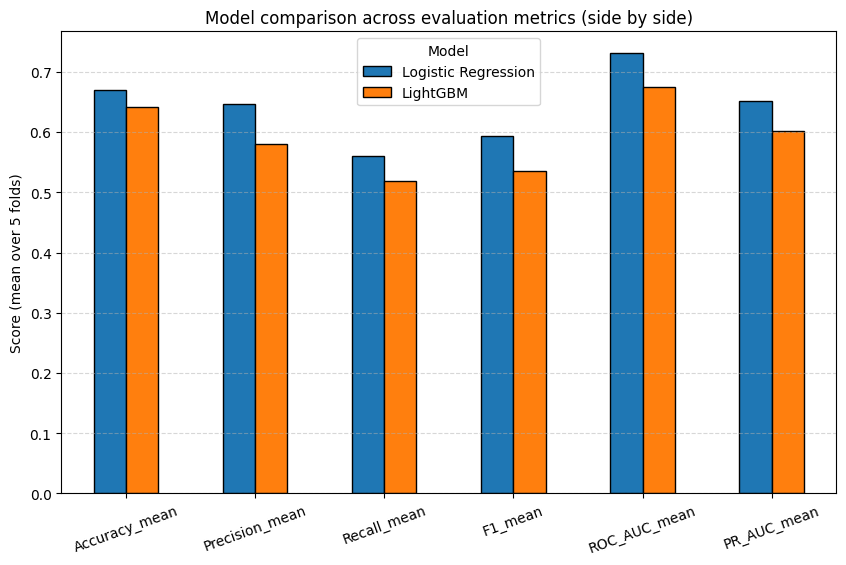

In [68]:
plot_metrics = [
    "Accuracy_mean",
    "Precision_mean",
    "Recall_mean",
    "F1_mean",
    "ROC_AUC_mean",
    "PR_AUC_mean",
]

plot_df = comparison.set_index("Model")[plot_metrics].T  # metrics as rows, models as columns


ax = plot_df.plot.bar(rot=20, figsize=(10, 6), edgecolor="black")
ax.set_ylabel("Score (mean over 5 folds)")
ax.set_title("Model comparison across evaluation metrics (side by side)")
ax.legend(title="Model")
ax.grid(axis="y", linestyle="--", alpha=0.5)



## ✅ Auswahl des finalen Modells

Die **logistische Regression** erzielte den **höchsten F1-Score**  
und zeigte **stabile Ergebnisse über alle Folds** hinweg.

---

### 🔍 Weitere Vorteile:
- Bessere **Interpretierbarkeit** der Einflussfaktoren  
  durch Analyse der **Modellkoeffizienten**

---

Aufgrund dieser Ergebnisse wurde die **logistische Regression**  
als **finales Modell ausgewählt** und anschließend auf dem **vollständigen Datensatz trainiert**.


In [69]:
pipeline_lr.fit(X_encoded, y)

print("Final model (Logistic Regression) trained on full dataset.")

Final model (Logistic Regression) trained on full dataset.


In [70]:
import joblib

joblib.dump(pipeline_lr, "../data/processed/final_model_logreg.joblib")

print("Final Logistic Regression model saved to data/processed/final_model_logreg.joblib")


Final Logistic Regression model saved to data/processed/final_model_logreg.joblib


In [71]:
model = pipeline_lr.named_steps["model"]

coef_series = (
    pd.Series(model.coef_[0], index=X_encoded.columns)
      .sort_values()
)

print("Stärkste negative Koeffizienten (senken Top-10-Wahrscheinlichkeit):")
print(coef_series.head(15))

print("\nStärkste positive Koeffizienten (erhöhen Top-10-Wahrscheinlichkeit):")
print(coef_series.tail(15))

Stärkste negative Koeffizienten (senken Top-10-Wahrscheinlichkeit):
season                  -0.762141
era_1990-2009           -0.557309
era_1970-1989           -0.517045
era_2010-2021           -0.324756
circuitId_64            -0.222552
grid_bucket_mid_11_20   -0.202935
era_2022+               -0.197997
circuitId_58            -0.175768
circuitId_35            -0.149998
circuitId_19            -0.140973
circuitId_60            -0.120455
circuitId_67            -0.113303
driverId                -0.110380
circuitId_68            -0.108856
circuitId_12            -0.101384
dtype: float64

Stärkste positive Koeffizienten (erhöhen Top-10-Wahrscheinlichkeit):
circuitId_62    0.069972
circuitId_76    0.080580
circuitId_6     0.087031
circuitId_53    0.096285
circuitId_45    0.101939
circuitId_75    0.127468
circuitId_52    0.130735
circuitId_61    0.132993
circuitId_65    0.142558
circuitId_54    0.168686
round           0.173087
circuitId_25    0.207814
circuitId_49    0.236218
circuitId_51

## 🏁 Ergebnis des Modelltrainings

Das finale Modell lernt aus vor dem Rennen bekannten Merkmalen die Wahrscheinlichkeit einer Top-10-Platzierung.

- Validierung: Stratifizierte CV für eine robuste Gesamteinschätzung und TimeSeriesSplit für eine zeitlich korrekte Prognose ohne Zukunfts-Leck. 
- Holdout: Das letzte Rennen im Datensatz bleibt außen vor und dient als realitätsnaher Test.

Damit liegt eine belastbare Vorhersagebasis für Vor-dem-Rennen-Prognosen vor.

